# Insurance Cost Prediction using Linear Regression

### The goal of this project is to predict medical insurance charges based on health, lifestyle, and financial factors using Linear Regression.

In [3]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import openpyxl as oxl

import matplotlib.pyplot as plt
import matplotlib as mlt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

## Dataset Description

### Features Description

- age: Age of the individual (in years)
- sex: Gender of the individual (male/female)
- bmi: Body Mass Index — a measure of body fat based on height and weight
- children: Number of dependents covered under insurance
- smoker: Indicates whether the individual is a smoker (yes/no)
- Claim_Amount: Amount claimed previously by the individual (historical claim data)
- past_consultations: Number of past medical consultations
- num_of_steps: Average daily steps (indicator of physical activity level)
- Hospital_expenditure: Previous hospital expenses incurred by the individual
- NUmber_of_past_hospitalizations: Total number of hospitalizations in the past
- Anual_Salary: Annual income of the individual
- region: Residential region (e.g., northeast, northwest, southeast, southwest)

### Target Variable
- charges: Medical insurance cost (dependent variable to be predicted)

In [4]:
# Loading dataset and Reading
df = pd.read_csv("insurance.csv",sep =",")
# Display first 5 rows
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


## Exploratory Data Analysis (EDA)
We analyze data distribution, relationships, and detect outliers to better understand feature behavior before modeling

In [5]:
df.shape

(1338, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [7]:
df.dtypes

age                                float64
sex                                 object
bmi                                float64
children                           float64
smoker                              object
Claim_Amount                       float64
past_consultations                 float64
num_of_steps                       float64
Hospital_expenditure               float64
NUmber_of_past_hospitalizations    float64
Anual_Salary                       float64
region                              object
charges                            float64
dtype: object

In [8]:
df.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1329.000000,1335.000000,1333.000000,1324.000000,1332.000000,1.335000e+03,1.334000e+03,1336.000000,1.332000e+03,1338.000000
mean,39.310008,30.665112,1.090773,33361.327180,15.216216,9.100047e+05,1.584179e+07,1.060629,3.696849e+08,13270.422265
std,14.034818,6.101690,1.201856,15617.288337,7.467723,9.188612e+04,2.669305e+07,0.533583,5.668843e+08,12110.011237
min,18.000000,15.960000,0.000000,1920.136268,1.000000,6.954300e+05,2.945253e+04,0.000000,2.747072e+06,1121.873900
25%,27.000000,26.302500,0.000000,20768.860390,9.000000,8.471995e+05,4.077633e+06,1.000000,7.701932e+07,4740.287150
50%,39.000000,30.400000,1.000000,33700.310675,15.000000,9.143000e+05,7.490337e+06,1.000000,1.419361e+08,9382.033000
75%,51.000000,34.687500,2.000000,45052.331957,20.000000,9.716840e+05,1.084082e+07,1.000000,3.243499e+08,16639.912515
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


In [9]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

## Data Cleaning
- Check for Null Values
- Check for Duplicates Values/Rows
- Check for outliers

In [10]:
#check for null values in dataset
#check for missing values
df.isnull()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
#sum of null values column-wise
df.isnull().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [12]:
#total count of null values in the dataset
df.isnull().sum().sum()

np.int64(52)

In [13]:
df.dropna(inplace = True)
#null values have been taken care as of now using the dropna function

In [14]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
#check for duplicate rows
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1287, dtype: bool

In [16]:
#sum of duplicated rows in the dataset
df.duplicated().sum()

np.int64(0)

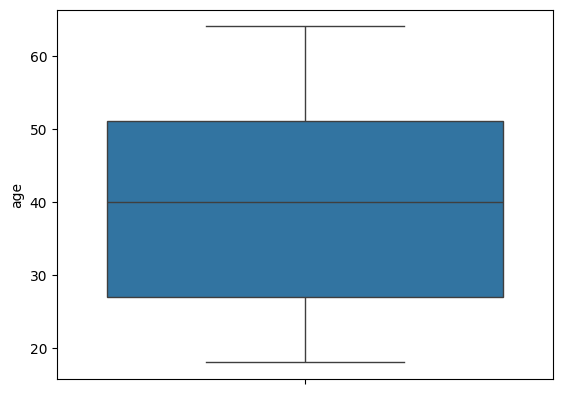

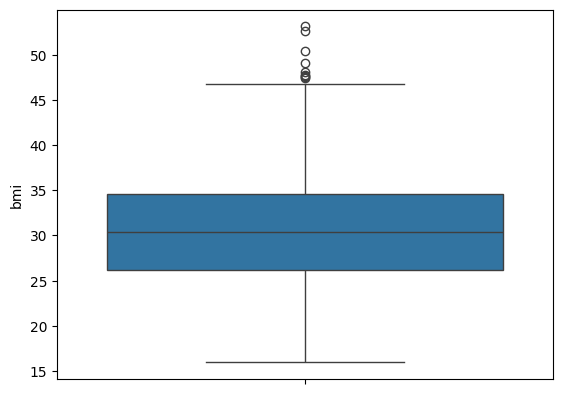

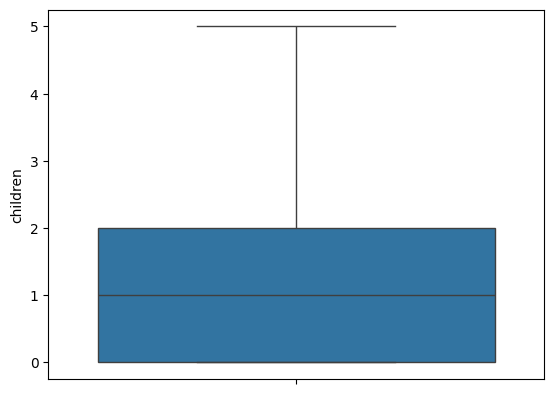

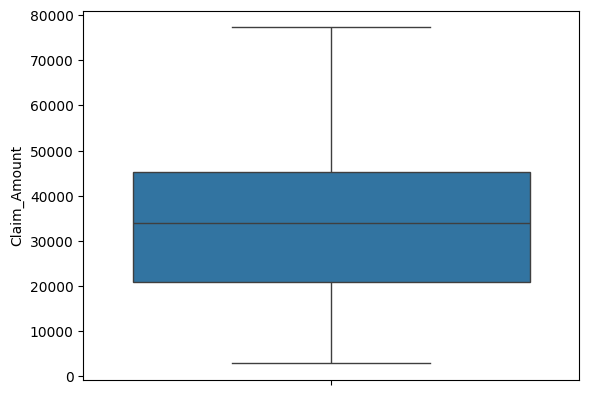

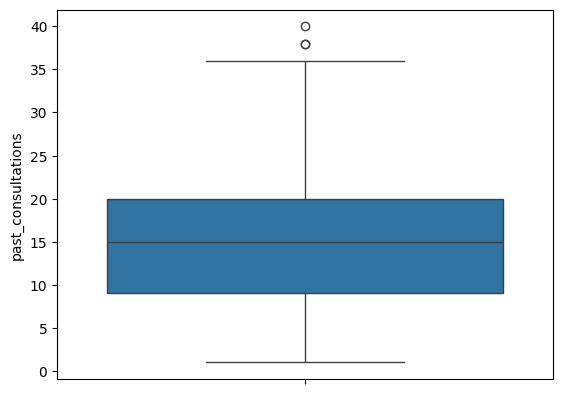

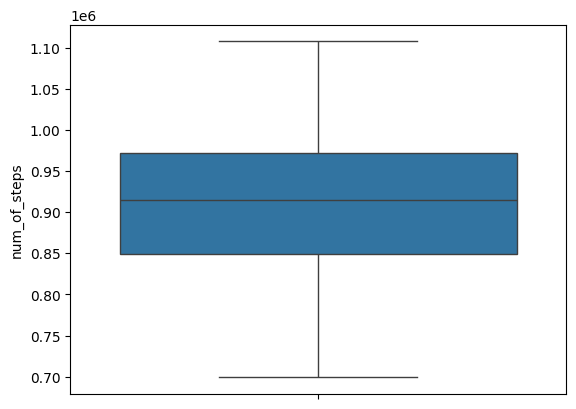

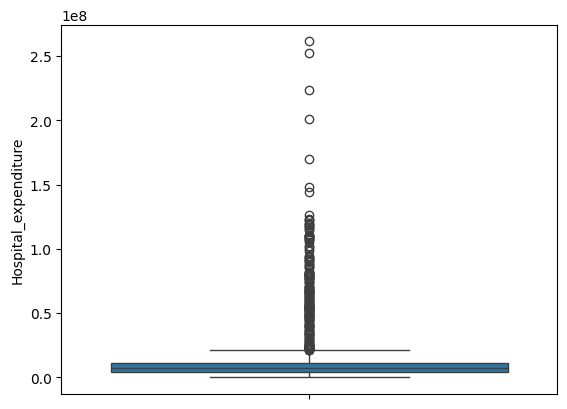

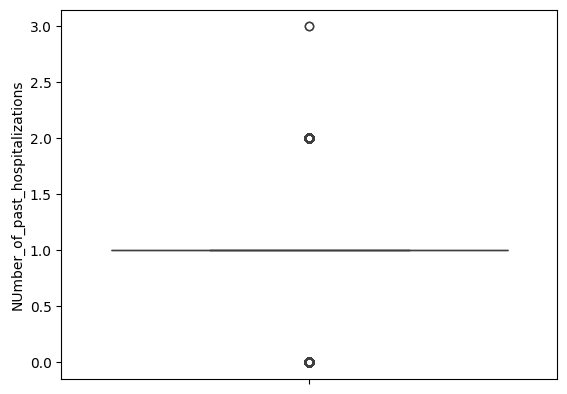

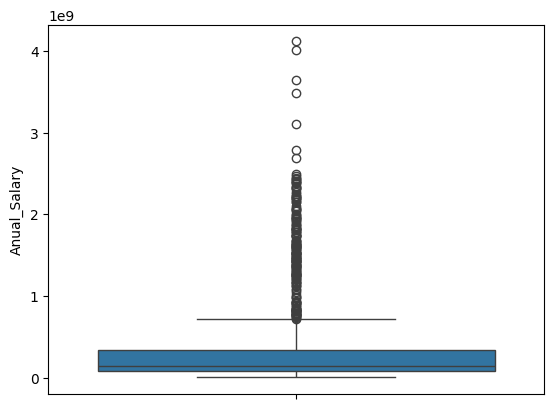

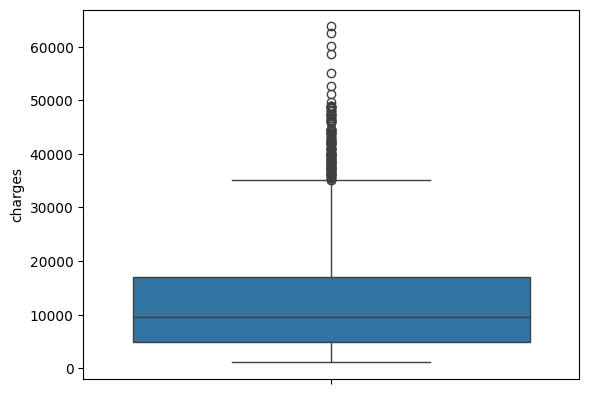

In [18]:
# outliers are detected using Boxplot
for i in df.columns:
    if df[i].dtypes != 'object':
        sns.boxplot(df[i])
        plt.show()

In [19]:
# Rmoving the outliers
for i in df.columns:
    if df[i].dtypes != 'object':
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1
        UL = Q3 + 1.5 * IQR
        LL = Q1 - 1.5 * IQR
        df = df[(df[i] >= LL) & (df[i] <= UL)]

## Data Visualization

### Histogram

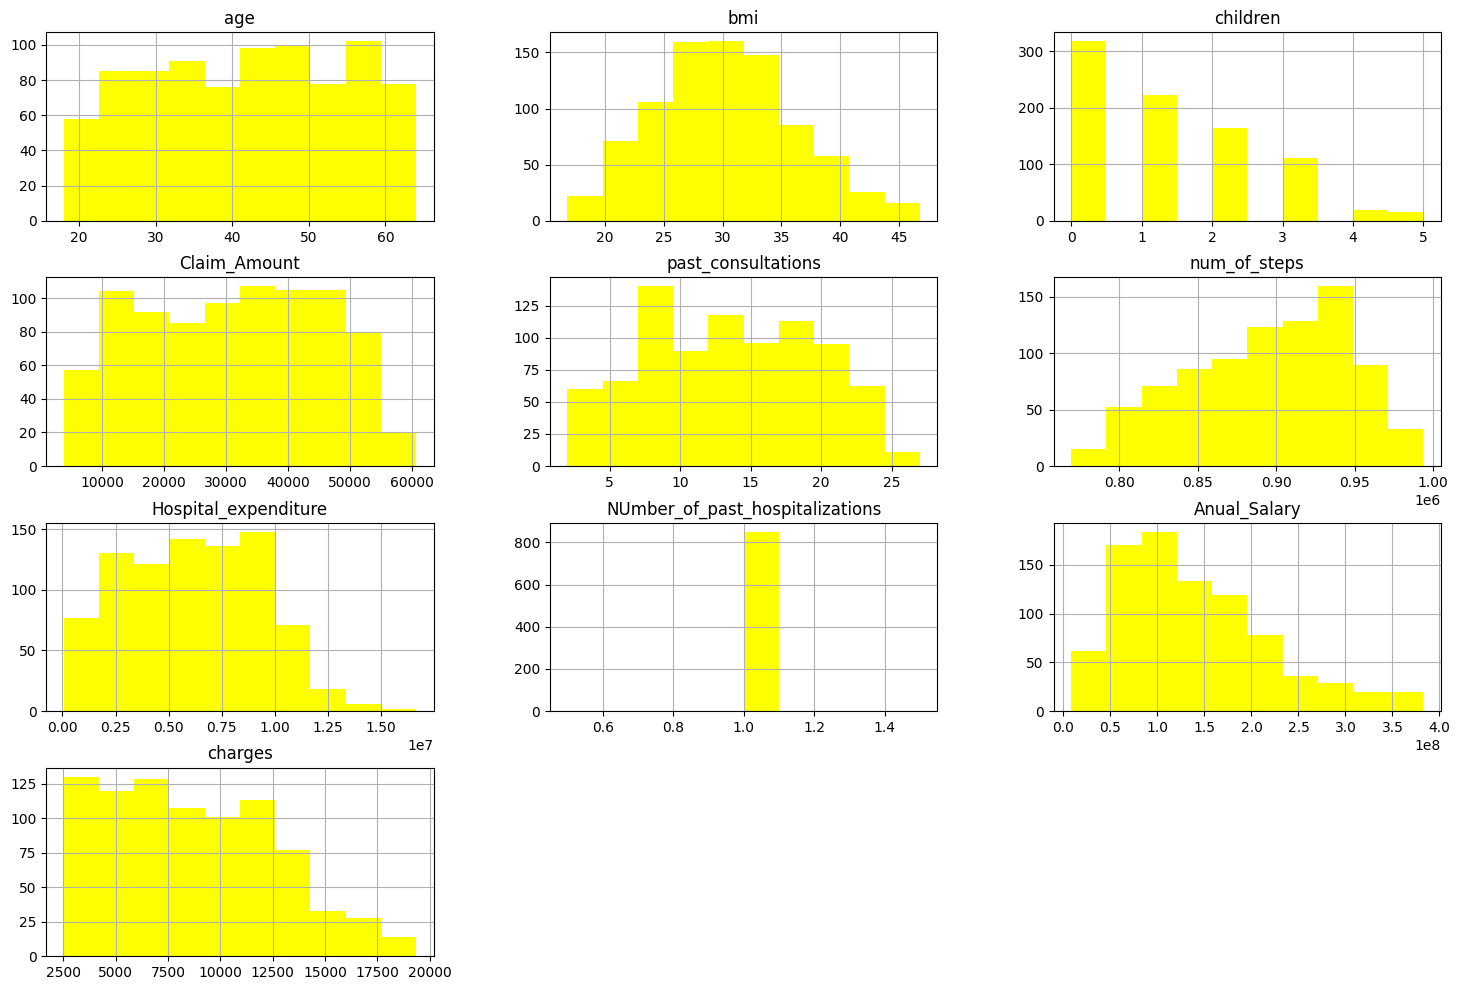

In [24]:
# Distribution of features
df.hist(figsize=(18,12), color='yellow')
plt.show()

### Correlation Heatmap


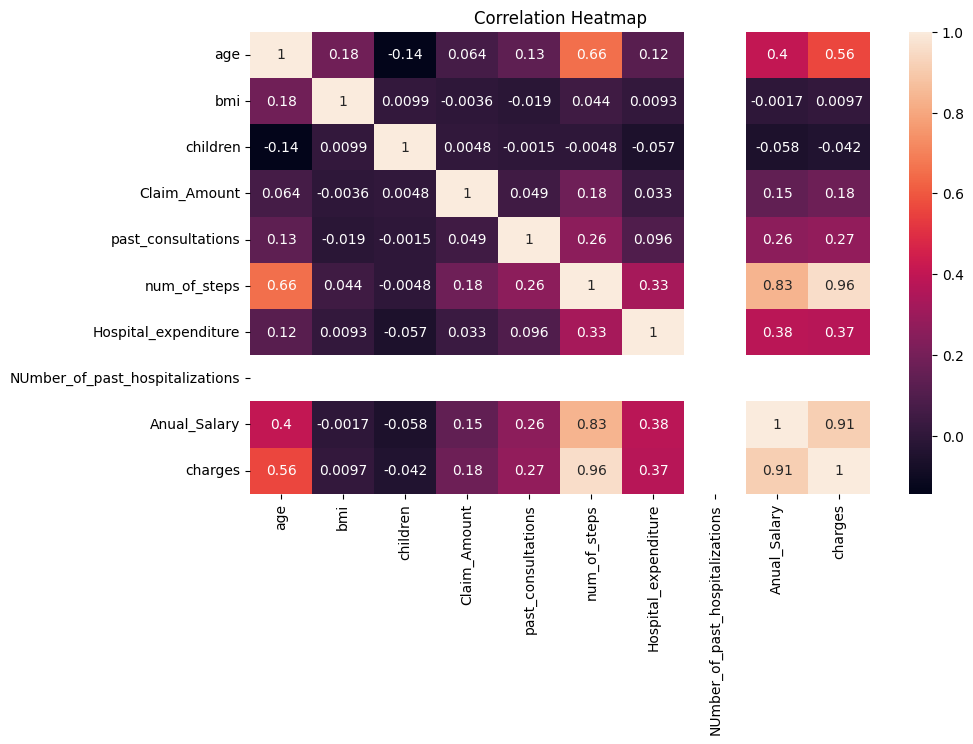

In [27]:
# Shows relationship between numerical features
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Smoker vs Charges (Key Insight)

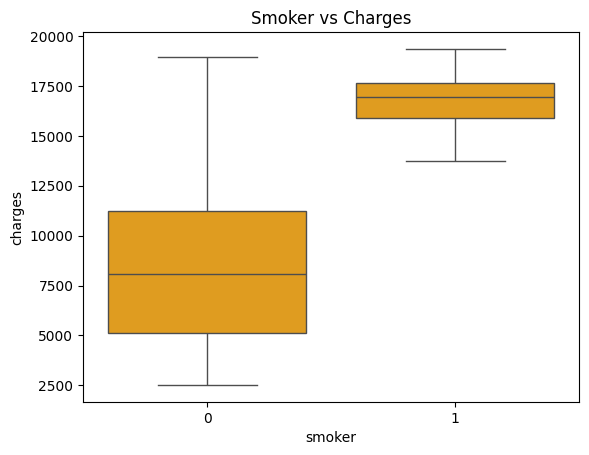

In [99]:
sns.boxplot(x=df['smoker'], y=df['charges'],color = 'orange')

plt.title("Smoker vs Charges")
plt.show()

In [100]:
# Smokers have significantly higher insurance charges.

### Scatter Plot

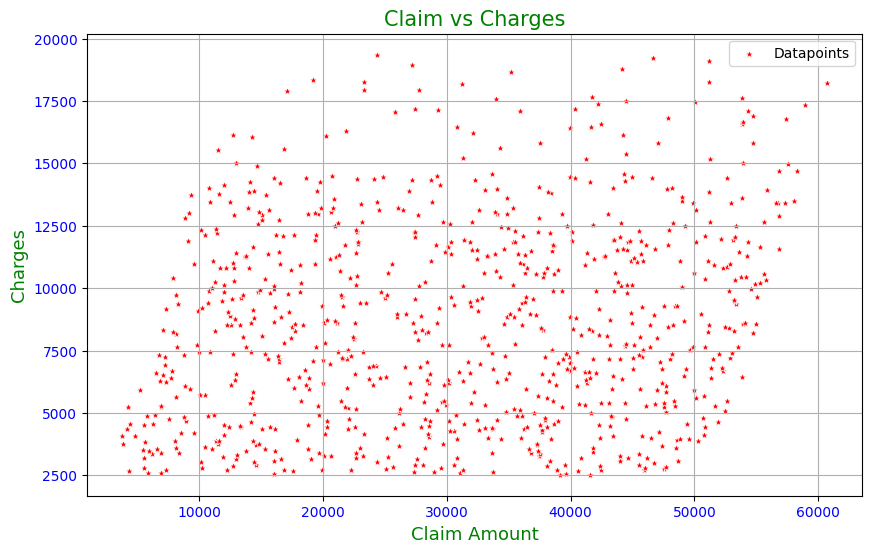

In [37]:
plt.figure(figsize = (10,6))
sns.scatterplot(x=df['Claim_Amount'], y=df['charges'],marker = "*",color = "red",label = "Datapoints")
plt.xlabel("Claim Amount",fontsize = "13",color = "green")
plt.ylabel("Charges",fontsize = "13",color = "green")
plt.title("Claim vs Charges",color = "green",fontsize = 15)
plt.xticks(color = "blue")
plt.yticks(color = "blue")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
df.shape

(851, 13)

## Multicollinearity Check using VIF

Variance Inflation Factor (VIF) is used to detect multicollinearity among independent variables.

- VIF = 1 → No correlation  
- VIF between 1–5 → Moderate correlation  
- VIF > 5 (or 6) → High multicollinearity  

In this project, we remove features with high VIF values (> 6) to improve model stability and interpretability.

In [51]:
xx = []
for i in df.columns:
    if (df[i].dtype != "object") and (i != "charges"):
        xx.append(i)

In [52]:
for i,col in enumerate(xx,0):
    print(i," -- ",col)

0  --  age
1  --  bmi
2  --  children
3  --  Claim_Amount
4  --  past_consultations
5  --  num_of_steps
6  --  Hospital_expenditure
7  --  NUmber_of_past_hospitalizations
8  --  Anual_Salary


In [53]:
xdf = df[xx]
xdf.sample(5)

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary
1005,27.0,30.590,1.0,47867.58146,15.0,971495.0,7477021.567,1.0,3.797889e+08
613,47.0,29.370,1.0,34628.74698,4.0,892575.0,5763826.196,1.0,9.273832e+07
324,37.0,30.800,0.0,51914.32544,21.0,849392.0,7946235.536,1.0,1.150965e+08
825,59.0,26.400,0.0,21761.74506,18.0,927015.0,5876375.487,1.0,2.315195e+08
199,21.0,16.815,1.0,16615.52026,4.0,811626.0,2938533.377,1.0,9.217500e+07


In [49]:
xdf.shape

(851, 9)

In [56]:
vi = [variance_inflation_factor(xdf.values,i) for i in range(len(xdf.columns))]
vif = pd.DataFrame({"Column_Name":xdf.columns,"VIF_Score":vi})
vif

,Column_Name,VIF_Score
0,age,2.244063
1,bmi,1.050993
2,children,1.077404
3,Claim_Amount,1.040690
4,past_consultations,1.080557
5,num_of_steps,5.999974
6,Hospital_expenditure,1.182321
7,NUmber_of_past_hospitalizations,1405.296038
8,Anual_Salary,4.006099


In [57]:
xdf = xdf.drop(columns = "NUmber_of_past_hospitalizations")
vi = [variance_inflation_factor(xdf.values,i) for i in range(len(xdf.columns))]
vif = pd.DataFrame({"Column_Name":xdf.columns,"VIF_Score":vi})
vif

,Column_Name,VIF_Score
0,age,16.334839
1,bmi,26.966942
2,children,2.055611
3,Claim_Amount,5.813854
4,past_consultations,6.417597
5,num_of_steps,58.693809
6,Hospital_expenditure,5.524176
7,Anual_Salary,6.183456


In [58]:
xdf = xdf.drop(columns = "num_of_steps")
vi = [variance_inflation_factor(xdf.values,i) for i in range(len(xdf.columns))]
vif = pd.DataFrame({"Column_Name":xdf.columns,"VIF_Score":vi})
vif

,Column_Name,VIF_Score
0,age,13.463550
1,bmi,14.548677
2,children,1.945699
3,Claim_Amount,5.267436
4,past_consultations,5.911489
5,Hospital_expenditure,5.218410
6,Anual_Salary,5.990854


In [59]:
xdf = xdf.drop(columns = "bmi")
vi = [variance_inflation_factor(xdf.values,i) for i in range(len(xdf.columns))]
vif = pd.DataFrame({"Column_Name":xdf.columns,"VIF_Score":vi})
vif

,Column_Name,VIF_Score
0,age,8.739225
1,children,1.827241
2,Claim_Amount,4.846444
3,past_consultations,5.589741
4,Hospital_expenditure,4.889264
5,Anual_Salary,5.841066


In [60]:
xdf = xdf.drop(columns = "age")
vi = [variance_inflation_factor(xdf.values,i) for i in range(len(xdf.columns))]
vif = pd.DataFrame({"Column_Name":xdf.columns,"VIF_Score":vi})
vif

,Column_Name,VIF_Score
0,children,1.816913
1,Claim_Amount,4.264550
2,past_consultations,4.927842
3,Hospital_expenditure,4.672553
4,Anual_Salary,5.107190


### We iteratively removed features with the highest VIF values until all features had VIF below the threshold.

This ensures:
- Reduced multicollinearity
- More stable model coefficients
- Better interpretability

### Observation:
- Some features showed high multicollinearity (VIF > 6)
- These features were removed iteratively
- Final dataset contains independent features suitable for regression

## This step improves model reliability and is commonly used in real-world regression problems.

### We iteratively removed features with the highest VIF values until all features had VIF below the threshold.

This ensures:
- Reduced multicollinearity
- More stable model coefficients
- Better interpretability

### Observation:
- Some features showed high multicollinearity (VIF > 6)
- These features were removed iteratively
- Final dataset contains independent features suitable for regression

## This step improves model reliability and is commonly used in real-world regression problems.

In [61]:
le = LabelEncoder()
for i in df.columns:
    if df[i].dtype == "object":
        df[i] = le.fit_transform(df[i])

In [62]:
df.dtypes

age                                float64
sex                                  int64
bmi                                float64
children                           float64
smoker                               int64
Claim_Amount                       float64
past_consultations                 float64
num_of_steps                       float64
Hospital_expenditure               float64
NUmber_of_past_hospitalizations    float64
Anual_Salary                       float64
region                               int64
charges                            float64
dtype: object

## Train-Test-Split

In [63]:
X = df.loc[:,['children','Claim_Amount','past_consultations','Hospital_expenditure','sex','Anual_Salary','smoker']]
y = df['charges']

In [64]:
#Split the data into training and testing data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

## Model Training

In [65]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


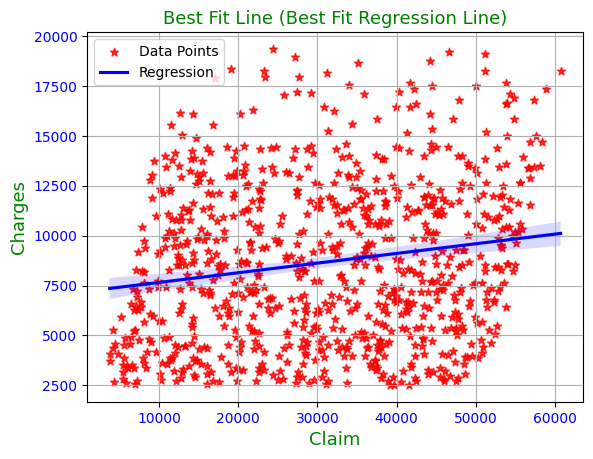

In [96]:
#line of Best-Fit Visualization
xx = df['Claim_Amount']
yy = df['charges']

# Explicitly define x and y
sns.regplot(x=xx, y=yy, marker="*", color="r",line_kws={"color": "blue","label":"Regression"},label = "Data Points")

plt.xlabel("Claim",fontsize = 13,color = "green")
plt.ylabel("Charges",fontsize = 13,color = "green")
plt.title("Best Fit Line (Best Fit Regression Line)",fontsize = 13,color = "green")
plt.xticks(color = "blue")
plt.yticks(color = "blue")
plt.legend()
plt.grid(True)
plt.show()

In [67]:
model.coef_
#here are the values of w's from w1 to w13
#the eqn of the line becomes y = w1x1 + w2x2 + w3x3 + .....+ w13x13 + c

array([ 3.67630233e+01,  1.18973939e-02,  1.90915307e+01,  4.03912301e-05,
       -4.64397496e+01,  4.42200259e-05, -3.01839813e+02])

In [68]:
model.intercept_
#here is the value of intercept that is c

np.float64(1596.5606040717448)

## Equation of Best Fit Regression line

In [70]:
# Display coefficients along with respective features
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coeff_df)
print("\nIntercept:", model.intercept_)

                Feature  Coefficient
0              children    36.763023
1          Claim_Amount     0.011897
2    past_consultations    19.091531
3  Hospital_expenditure     0.000040
4                   sex   -46.439750
5          Anual_Salary     0.000044
6                smoker  -301.839813

Intercept: 1596.5606040717448


In [71]:
eq = f"y = {model.intercept_:.2f}"

for coef, col in zip(model.coef_, X.columns):
    eq += f" + ({coef:.2f} * {col})"

print("The equation of the best file lines is as follows :- \n")
print(eq)

The equation of the best file lines is as follows :- 

y = 1596.56 + (36.76 * children) + (0.01 * Claim_Amount) + (19.09 * past_consultations) + (0.00 * Hospital_expenditure) + (-46.44 * sex) + (0.00 * Anual_Salary) + (-301.84 * smoker)


# Prediction

## Comparision of Actual and Predicted

In [73]:
y_pred = model.predict(X_test)
y_pred

array([ 6698.1676059 ,  4957.04092734,  9818.14411257, 14322.11035023,
        7757.44728998, 11033.18683719,  9407.05277052, 14652.2794546 ,
       12865.19967771, 13434.36231897, 10097.2284457 , 10888.41117614,
       10354.42525803,  7741.33908642,  9619.50183091,  5563.86529987,
        6091.43280836, 10565.73686809, 13987.92432622, 17485.84375831,
        5242.44852777, 10240.49013096, 15563.96955751,  6976.43850869,
       10943.86944738, 14031.4195062 ,  4830.79666395, 13007.37880717,
        8370.08461847,  7183.9941731 ,  8998.90157471,  6900.7035991 ,
       10605.10490255, 12589.30190131,  9185.82906008,  9019.64662608,
        6704.95636183,  7835.58870248,  6137.69192076,  8848.86186376,
        6957.50082783, 10454.16279301,  7986.32298115,  5474.74406782,
        5378.52343173,  7962.68369623,  7644.29752342,  8331.39273968,
        5438.93717314,  5546.29476893, 15972.01025729,  8218.90542058,
        5560.04114387,  9177.20492849,  9152.97615483,  7477.31157443,
      

In [74]:
y_pred.shape

(171,)

In [75]:
#how much our predictions are close to actual prices
results = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
results.head()
#displaying first 5 rows

,Actual,Predicted
218,3353.47030,6698.167606
486,6753.03800,4957.040927
839,11884.04858,9818.144113
980,15006.57945,14322.110350
568,7985.81500,7757.447290


# Model Evaluation

In [76]:
print("R2_Score :-",r2_score(y_test,y_pred)) # model accuracy
print("Mean Squared Error :- ",mean_squared_error(y_test,y_pred))

R2_Score :- 0.826434654080062
Mean Squared Error :-  2635673.9965366367


In [77]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred)) #mse ** 0.5 -- Square root of Mean Squared Error
print("Root Mean Squared Error :- ",rmse)

Root Mean Squared Error :-  1623.47589958602


# Example custom input

In [79]:
X.columns

Index(['children', 'Claim_Amount', 'past_consultations',
       'Hospital_expenditure', 'sex', 'Anual_Salary', 'smoker'],
      dtype='object')

In [81]:
# Order must match X.columns

custom_input = [[0.0, 14630.20499, 8.0, 6323439.271, 0, 282078392.0, 0]]

predicted_price = model.predict(custom_input)

print("Predicted Price:", predicted_price[0])

Predicted Price: 14652.279454595911


F:\Python_Files2026\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [80]:
X.sample()

,children,Claim_Amount,past_consultations,Hospital_expenditure,sex,Anual_Salary,smoker
978,0.0,14630.20499,8.0,6323439.271,0,282078392.0,0


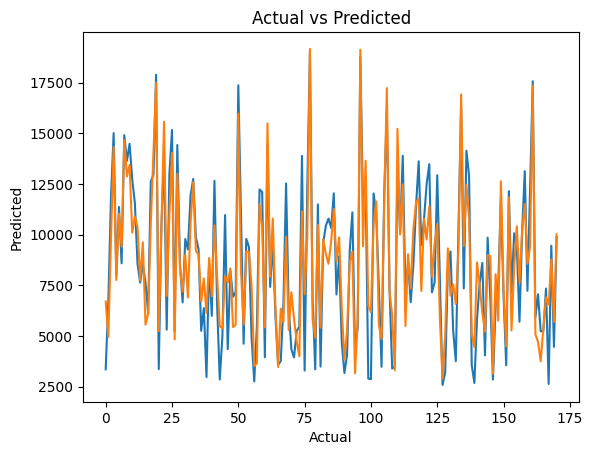

In [82]:
#plt.scatter(y_test, y_pred)
plt.plot(y_test.values)
plt.plot(y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()